# Data Preparation for EIS RL Training

This notebook walks through how to prepare EIS (Electrochemical Impedance Spectroscopy) data for training the reinforcement learning agent.

## What You'll Learn
1. How to load raw CSV files
2. How to process and validate EIS data
3. How to save processed data for reuse
4. How to load existing processed data
5. Understanding the data structure

## Prerequisites
- CSV files with columns: `freq`, `Z_real`, `Z_imag`
- OR pre-processed pickle file

In [1]:
# Imports
%matplotlib inline
from autorec.data_preparation import EISDataPrep
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import autoeis as ae
from pathlib import Path

# Set display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

---
## Option 1: Load Existing Processed Data

If you already have a processed pickle or CSV file, this is the fastest way to get started.

In [2]:
# Load existing processed data
data_prep = EISDataPrep(
    path='../data/training_dataset.pkl',  # Path to your pickle file
    mode='load',                 # Load mode (not process)
    evaluation=True              # Set to True if ground truth circuits available
)

# Load the dataset
dataset = data_prep.load()

print(f"Loaded {len(dataset)} EIS measurements")


Validation Warnings:
  ⚠ Dataset contains extra columns (will be ignored): Z_perfect, Z_perfect_flatten, chi_LinKK, r2_LinKK, chi_fit, r2_fit, true_state
  ⚠ Column 'sub_id' should contain string values

✓ Validation passed (1350 samples)
Loaded 1350 EIS measurements


In [3]:
# View summary statistics
summary = data_prep.get_summary()
print(summary)

DATASET SUMMARY
Mode: load
Evaluation Mode: True
Path: ../data/training_dataset.pkl
Total samples: 1350

Columns: ['sub_id', 'true_circuit', 'Z_perfect', 'Z_perfect_flatten', 'Z_true', 'chi_LinKK', 'r2_LinKK', 'chi_fit', 'r2_fit', 'chi_thresh', 'r2_thresh', 'true_state', 'freq', 'flatten_Z']

Data types:
sub_id                 int64
true_circuit          object
Z_perfect             object
Z_perfect_flatten     object
Z_true                object
chi_LinKK            float64
r2_LinKK             float64
chi_fit               object
r2_fit               float64
chi_thresh            object
r2_thresh            float64
true_state            object
freq                  object
flatten_Z             object
dtype: object

Shape: (1350, 14)

Circuit distribution:
true_circuit
R1-[R2,C3]                    270
R1-[R2-P3,C4]                 270
R1-[R2-[R3,C4],C5]            270
R1-[R2,C3]-[R4,C5]-P6         270
R1-[R2,C3]-[R4,C5]-[R6,C7]    270
Name: count, dtype: int64

Unique files/subfolder

In [4]:
# Examine the dataset structure
print("Dataset columns:")
print(dataset.columns.tolist())
print("\nFirst few rows:")
dataset.head()

Dataset columns:
['sub_id', 'true_circuit', 'Z_perfect', 'Z_perfect_flatten', 'Z_true', 'chi_LinKK', 'r2_LinKK', 'chi_fit', 'r2_fit', 'chi_thresh', 'r2_thresh', 'true_state', 'freq', 'flatten_Z']

First few rows:


,sub_id,true_circuit,Z_perfect,Z_perfect_flatten,Z_true,chi_LinKK,r2_LinKK,chi_fit,r2_fit,chi_thresh,r2_thresh,true_state,freq,flatten_Z
0,0,"R1-[R2,C3]","[(77.42637288765869-0.13122419973936264j), (77...","[77.42637288765869, -0.13122419973936264, 77.4...","[(77.25618984199498-0.08043147549643025j), (77...",6.069363e-09,1.000000,1.9863296e-06,0.999997,1.9863295e-05,0.999797,+R/RC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.9999480322902017, 0.9999538996575091, ..."
1,1,"R1-[R2,C3]","[(77.4263683170038-0.05931797918294896j), (77....","[77.4263683170038, -0.05931797918294896, 77.42...","[(77.20489061357662+0.03266263973510151j), (77...",9.826522e-07,1.000000,2.189271e-06,0.999998,2.1892709e-05,0.999798,+R/RC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.9999934236784858, 0.9999999530667902, ..."
2,2,"R1-[R2,C3]","[(46.41588833993719-0.01951765902521175j), (46...","[46.41588833993719, -0.01951765902521175, 46.4...","[(46.36433877874647-0.030766500391650027j), (4...",1.360470e-05,1.000000,1.9137597e-06,0.999997,1.9137597e-05,0.999797,+R/RC,"[81544.07395185171, 66494.35996665046, 54222.2...","[0.9999972517013115, 0.9999975736666616, 1.0, ..."
3,3,"R1-[R2,C3]","[(77.42636860820309-0.09551748942880718j), (77...","[77.42636860820309, -0.09551748942880718, 77.4...","[(77.4619410181077-0.0685245143541367j), (77.5...",1.911505e-02,0.943301,1.9340218e-06,0.999997,1.9340217e-05,0.999797,+R/RC,"[81544.07395185171, 66494.35996665046, 54222.2...","[0.9999957455773898, 1.0, 0.9999872252008559, ..."
4,4,"R1-[R2,C3]","[(12.915527709007959-0.3402569723701754j), (12...","[12.915527709007959, -0.3402569723701754, 12.9...","[(12.940598650641547-0.3496089677139219j), (12...",1.963297e-08,1.000000,2.1635283e-06,0.999996,2.1635282e-05,0.999796,+R/RC,"[81544.07395185171, 66494.35996665046, 54222.2...","[1.0, 0.9999673817448446, 0.9999113539458127, ..."


### Understanding the Dataset Columns

Each row is one EIS measurement. Required columns:

- **sub_id**: Identifier tracking which file the data came from
- **freq**: Array of frequency points (e.g., [0.1, 1, 10, ...])
- **Z_true**: Complex impedance array (real + imaginary)
- **flatten_Z**: Flattened, normalized representation for neural network
- **chi_thresh**: Chi-square threshold for determining good fit
- **r2_thresh**: R² threshold for determining good fit

If `evaluation=True`:
- **true_circuit**: Ground truth circuit string (e.g., 'R-p(R,C)')

In [5]:
# Look at a single EIS measurement in detail
idx = 0  # First EIS
eis_sample = dataset.iloc[idx]

print(f"EIS #{idx}:")
print(f"  Sub ID: {eis_sample['sub_id']}")
if 'true_circuit' in eis_sample:
    print(f"  True circuit: {eis_sample['true_circuit']}")
print(f"  Number of frequency points: {len(eis_sample['freq'])}")
print(f"  Frequency range: {eis_sample['freq'].min():.2e} to {eis_sample['freq'].max():.2e} Hz")
print(f"  Chi-square threshold: {eis_sample['chi_thresh']:.4f}")
print(f"  R² threshold: {eis_sample['r2_thresh']:.4f}")

EIS #0:
  Sub ID: 0
  True circuit: R1-[R2,C3]
  Number of frequency points: 79
  Frequency range: 1.00e-02 to 8.15e+04 Hz
  Chi-square threshold: 0.0000
  R² threshold: 0.9998


---
## Option 2: Process Raw CSV Files

If you have raw CSV files, you can process them into the required format.

### Expected Folder Structure:
```
EIS_raw_demo/
  ├── Name_1/
  │   ├── sample_001.csv
  │   ├── sample_002.csv
  │   └── ...
  ├── Name_2/
  │   ├── sample_001.csv
  │   └── ...
  └── ...
```

- Folder names can be an arbitrary name, or circuit labels if known (e.g., "+/RRR", "+RR"), or date of EIS acquisition or any other experimental labels (For example different electrochemical systems). If, the labels are circuit labels, they can be used later during agent's evaluation for comparison, otherwise the name will be used only to reference.
- Note that is the true circuit lables are not provided for the label names, you will see the "Invalid circuit formats found:" message during processing and the folder names will be stored in the true_circuit column of the proccessed panda dataframe. This is normal and will not affect the agent training as circuit labels are optional.
- The subfolder is optional. So, if there is no labeling is required for EIS, all raw files can be located inside the main folder (EIS_raw_demo) without any subfolder. The EISDataPrep is able to process both options automatically.
- Each CSV must have columns: `freq`, `Z_real`, `Z_imag`

In [6]:
# Uncomment to process raw CSV files

data_prep_raw = EISDataPrep(
    path='EIS_raw_demo',          # Folder containing subfolders with CSVs
    mode='process',             # Process raw files
    evaluation=True             # True if folder names are circuit labels
)

# This will take some time depending on number of files
dataset_raw = data_prep_raw.load()

print(f"Processed {len(dataset_raw)} EIS measurements")
print(data_prep_raw.get_summary())

Found 9 CSV files (including subfolders)
Across 3 folders/subfolders

Processed 9 samples successfully
Found 3 unique circuit types
Circuits: ['Name_1', 'Name_2', 'Name_3']

Validation Warnings:
  ⚠ Invalid circuit formats found: 3 circuits
  ⚠   - 'Name_1': Invalid element type: Name
  ⚠   - 'Name_2': Invalid element type: Name
  ⚠   - 'Name_3': Invalid element type: Name

✓ Validation passed (9 samples)
Processed 9 EIS measurements
DATASET SUMMARY
Mode: process
Evaluation Mode: True
Path: EIS_raw_demo
Total samples: 9

Columns: ['sub_id', 'true_circuit', 'freq', 'Z_true', 'flatten_Z', 'chi_thresh', 'r2_thresh']

Data types:
sub_id           object
true_circuit     object
freq             object
Z_true           object
flatten_Z        object
chi_thresh      float64
r2_thresh       float64
dtype: object

Shape: (9, 7)

Circuit distribution:
true_circuit
Name_1    4
Name_2    3
Name_3    2
Name: count, dtype: int64

Unique files/subfolders: 9

Sample flatten_Z length: 480
Sample freq l

In [7]:
# Save processed data for future use
# This avoids re-processing raw files every time

DIR = "./demo_output"  # Directory where the output will be saved for this demo

save_dir = Path(DIR)
save_dir.mkdir(parents=True, exist_ok=True)
data_prep_raw.save(f"{DIR}/processed_training_data.pkl")
print(f"Saved processed data to: {DIR}/processed_training_data.pkl")

Dataset saved to demo_output/processed_training_data.pkl
Saved processed data to: ./demo_output/processed_training_data.pkl


---
## Visualizing EIS Data

Let's plot some EIS measurements to understand what the data looks like.

/var/folders/rd/8_jgk8f131sdw6h12h0wfphw0000gn/T/ipykernel_23533/213258625.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


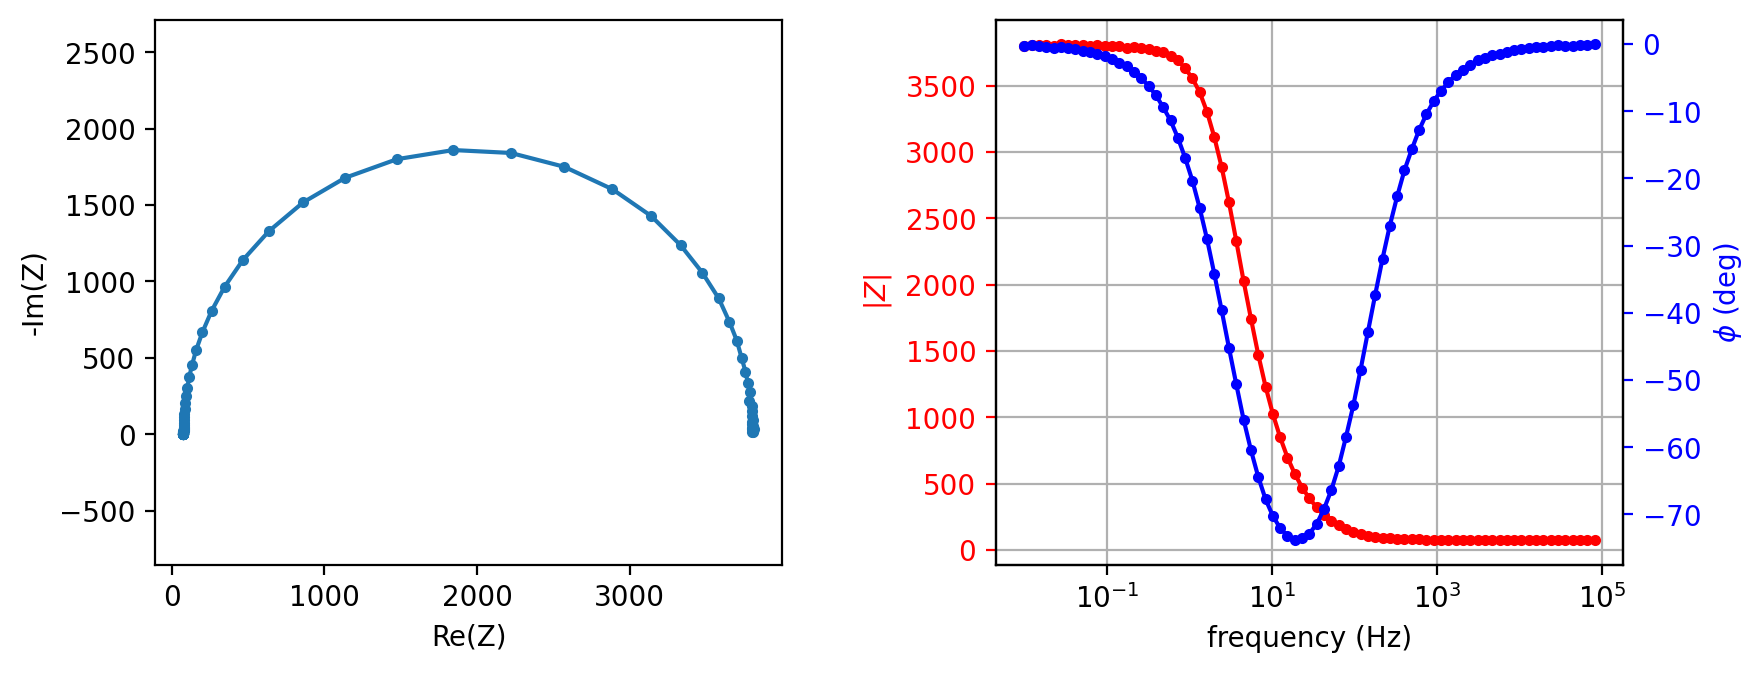

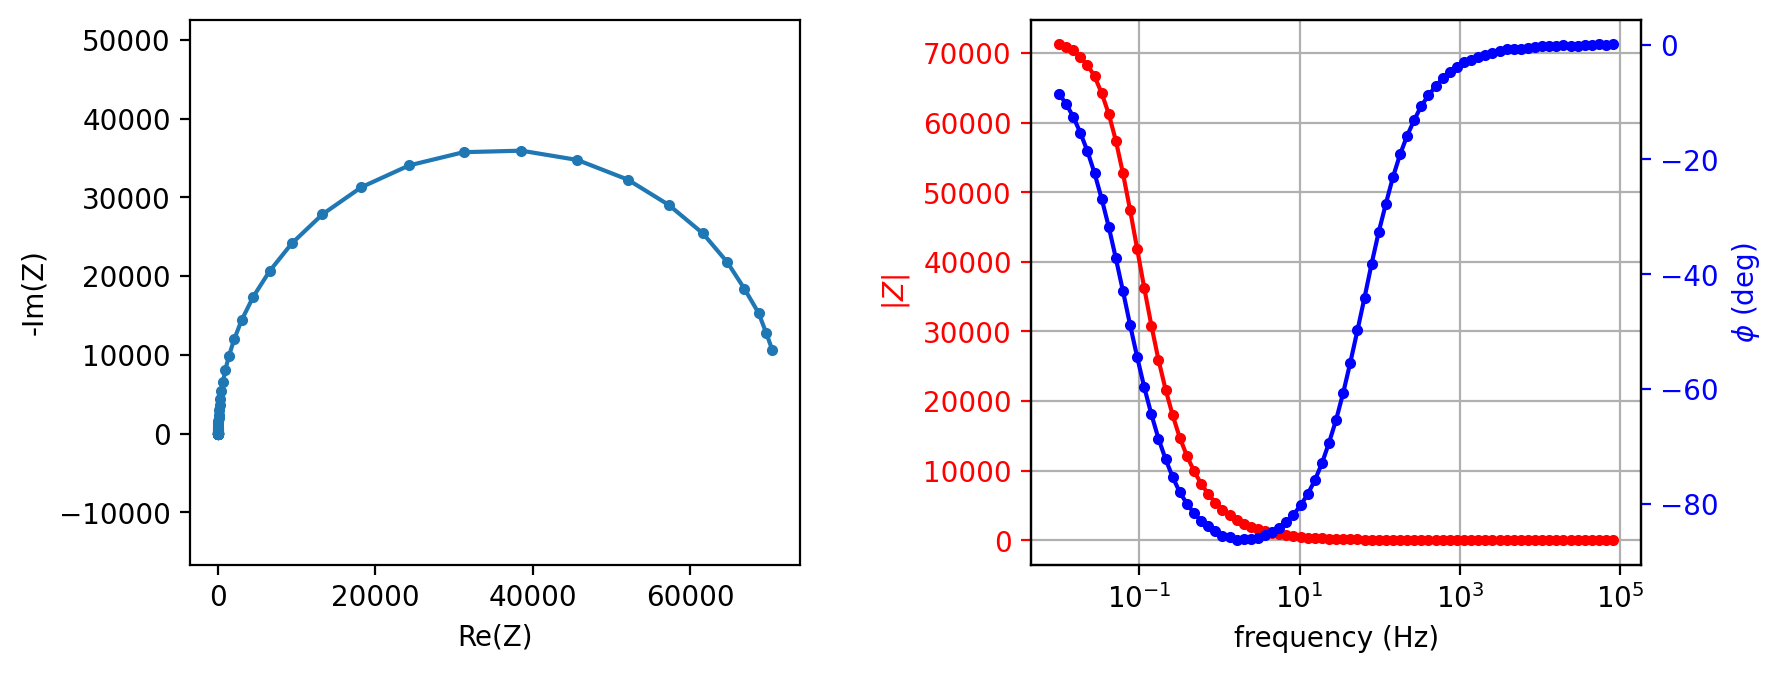

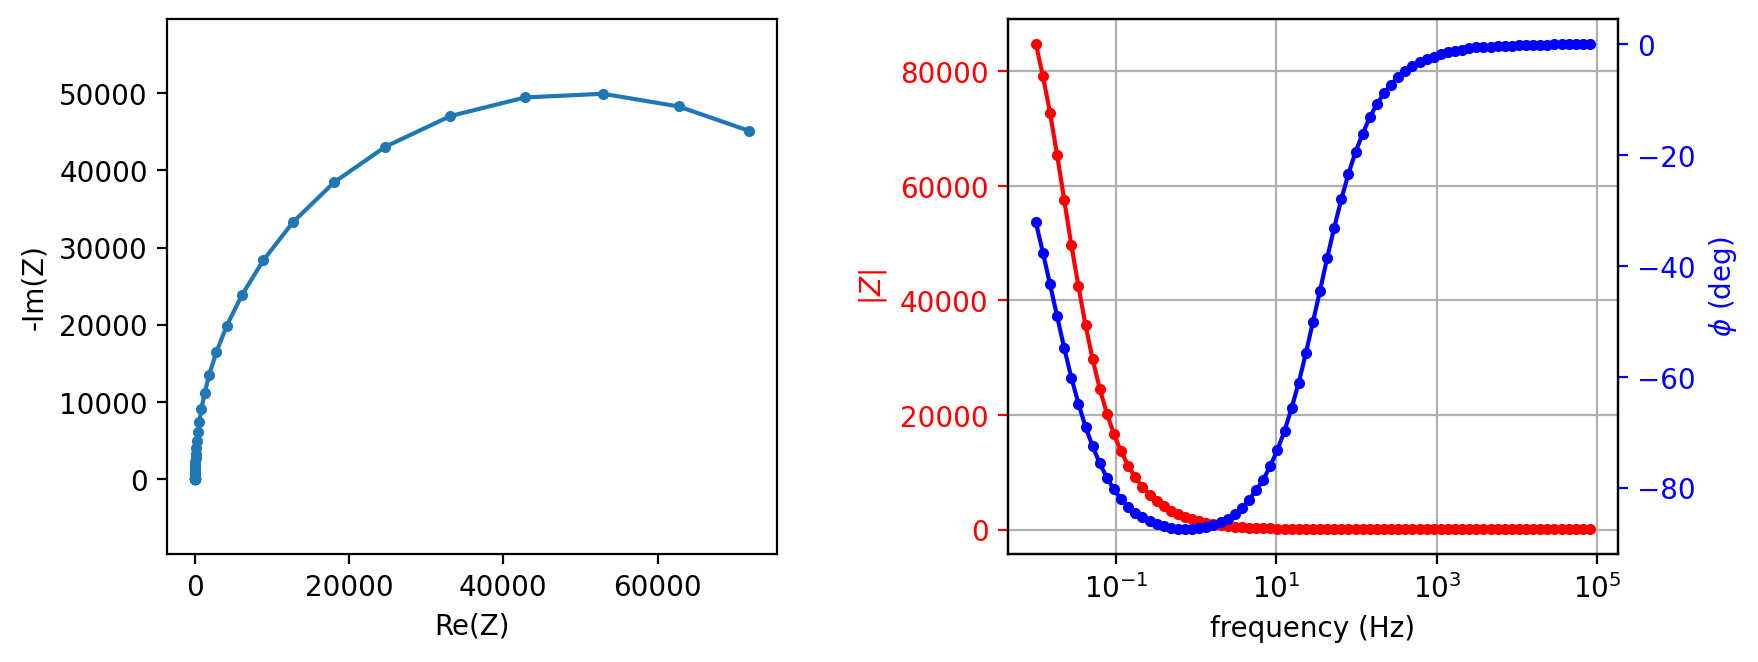

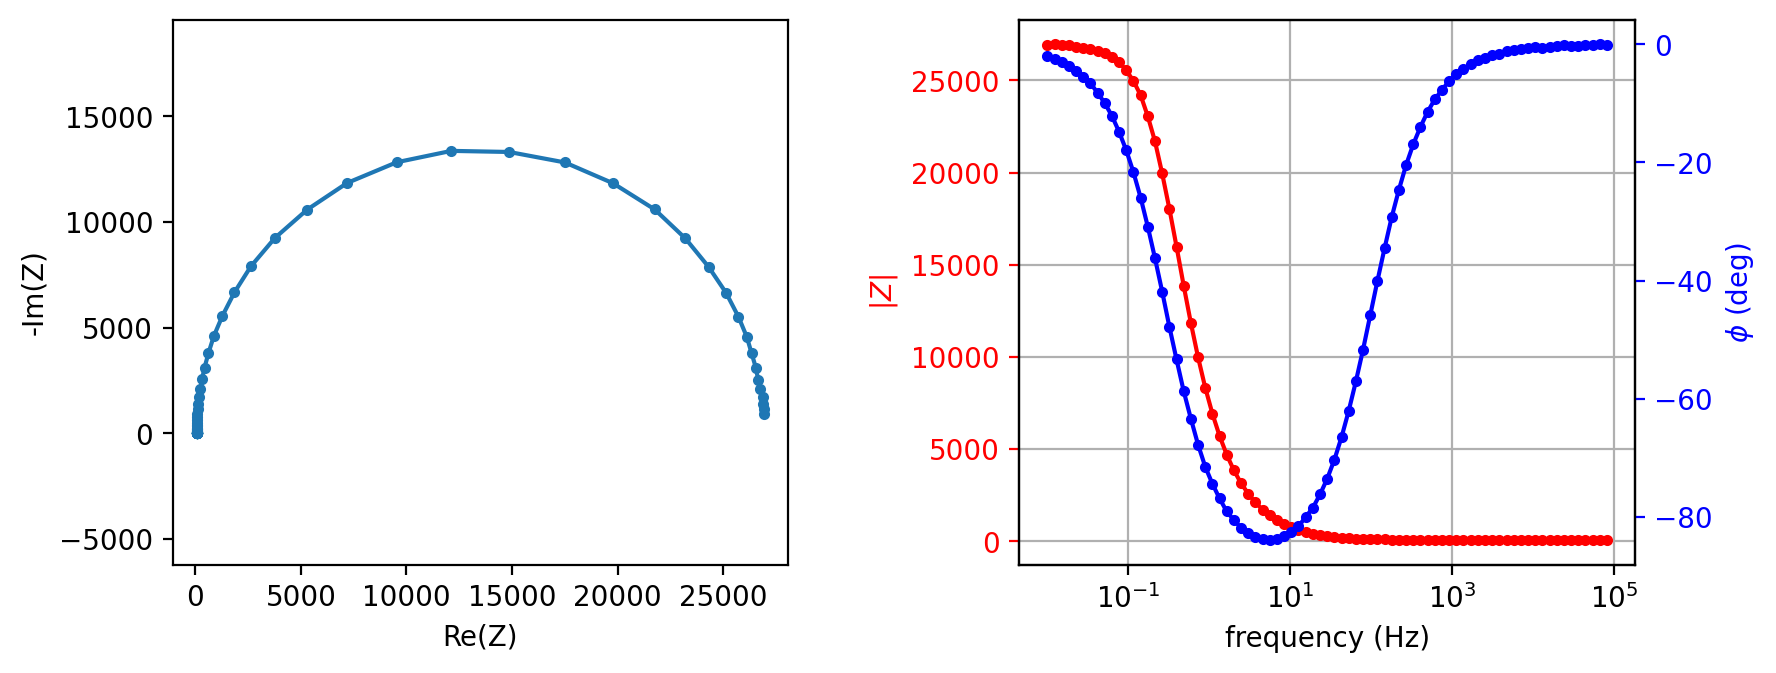

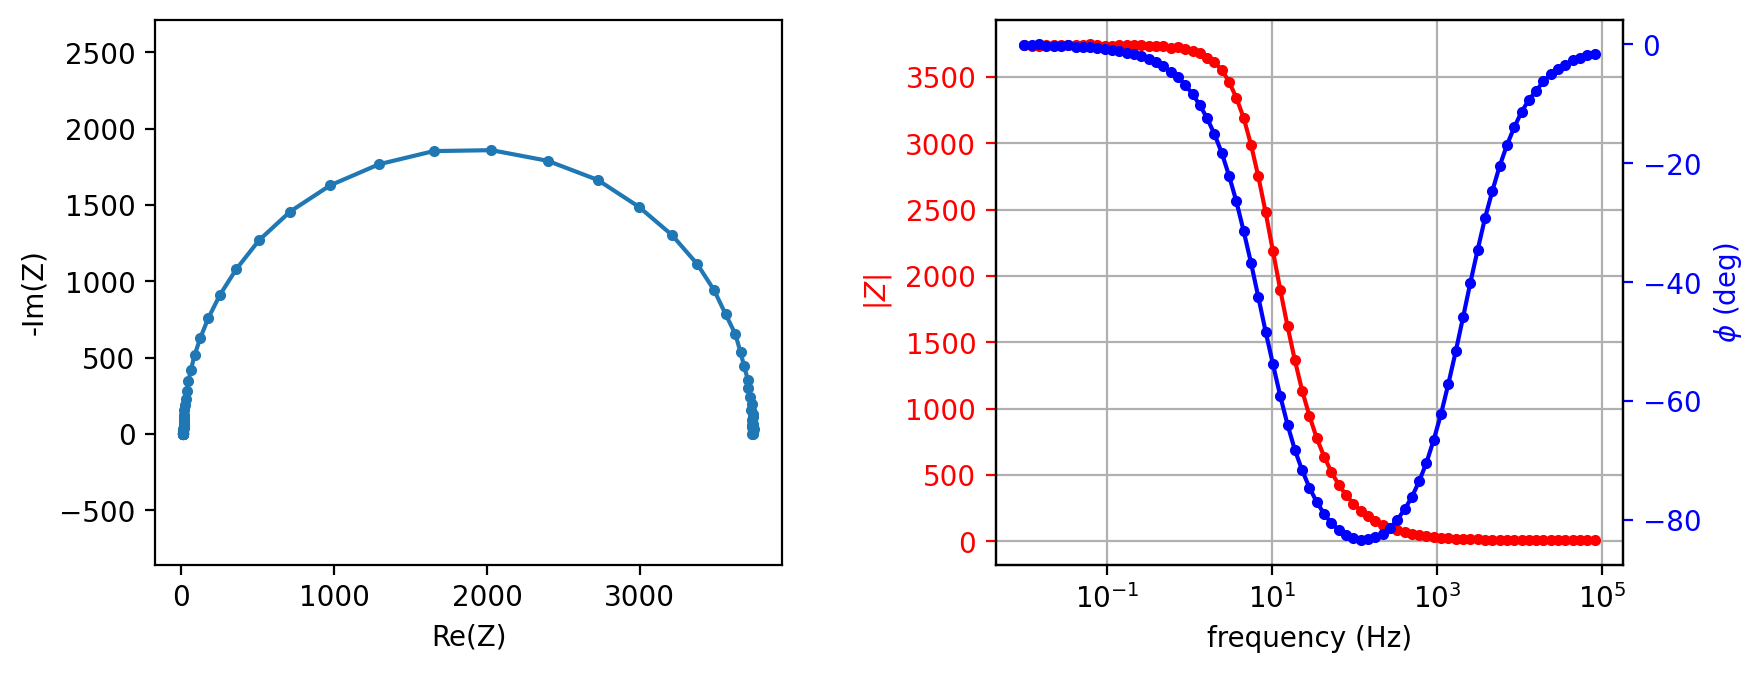

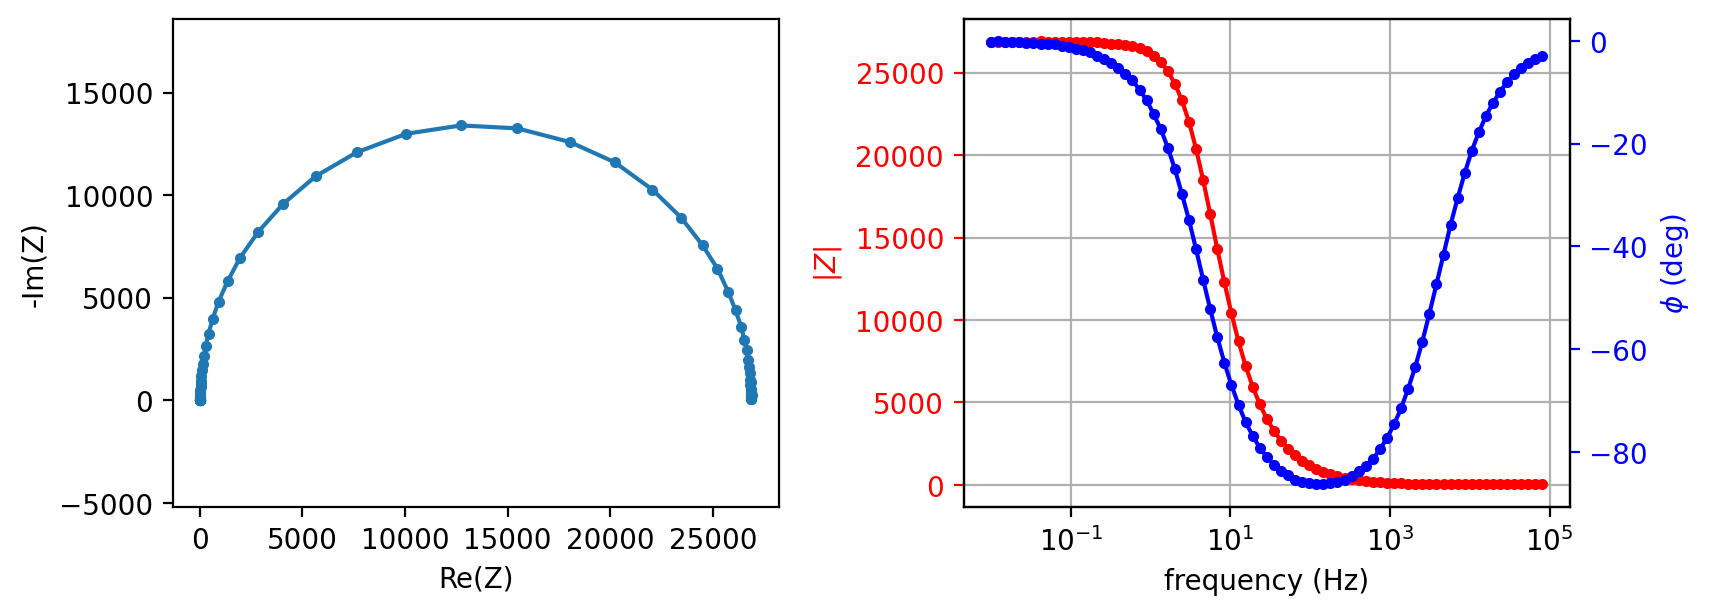

In [8]:
# Nyquist-Bode plot (imaginary vs real impedance)

for i in range(min(6, len(dataset))):
    eis = dataset.iloc[i]
    Z = eis['Z_true']
    freq = eis['freq']
    ax = ae.visualization.plot_impedance_combo(freq, Z)

plt.tight_layout()
plt.show()

---
## Data Statistics and Quality Checks

In [9]:
# Check if all EIS have same number of frequency points
freq_lengths = dataset['freq'].apply(len)
print(f"All EIS have {freq_lengths.iloc[0]} frequency points: {freq_lengths.nunique() == 1}")

if freq_lengths.nunique() > 1:
    print(f"Warning: Found {freq_lengths.nunique()} different frequency lengths!")
    print(freq_lengths.value_counts())

All EIS have 79 frequency points: True


Circuit Distribution:
true_circuit
R1-[R2,C3]                    270
R1-[R2-P3,C4]                 270
R1-[R2-[R3,C4],C5]            270
R1-[R2,C3]-[R4,C5]-P6         270
R1-[R2,C3]-[R4,C5]-[R6,C7]    270
Name: count, dtype: int64

Total unique circuits: 5


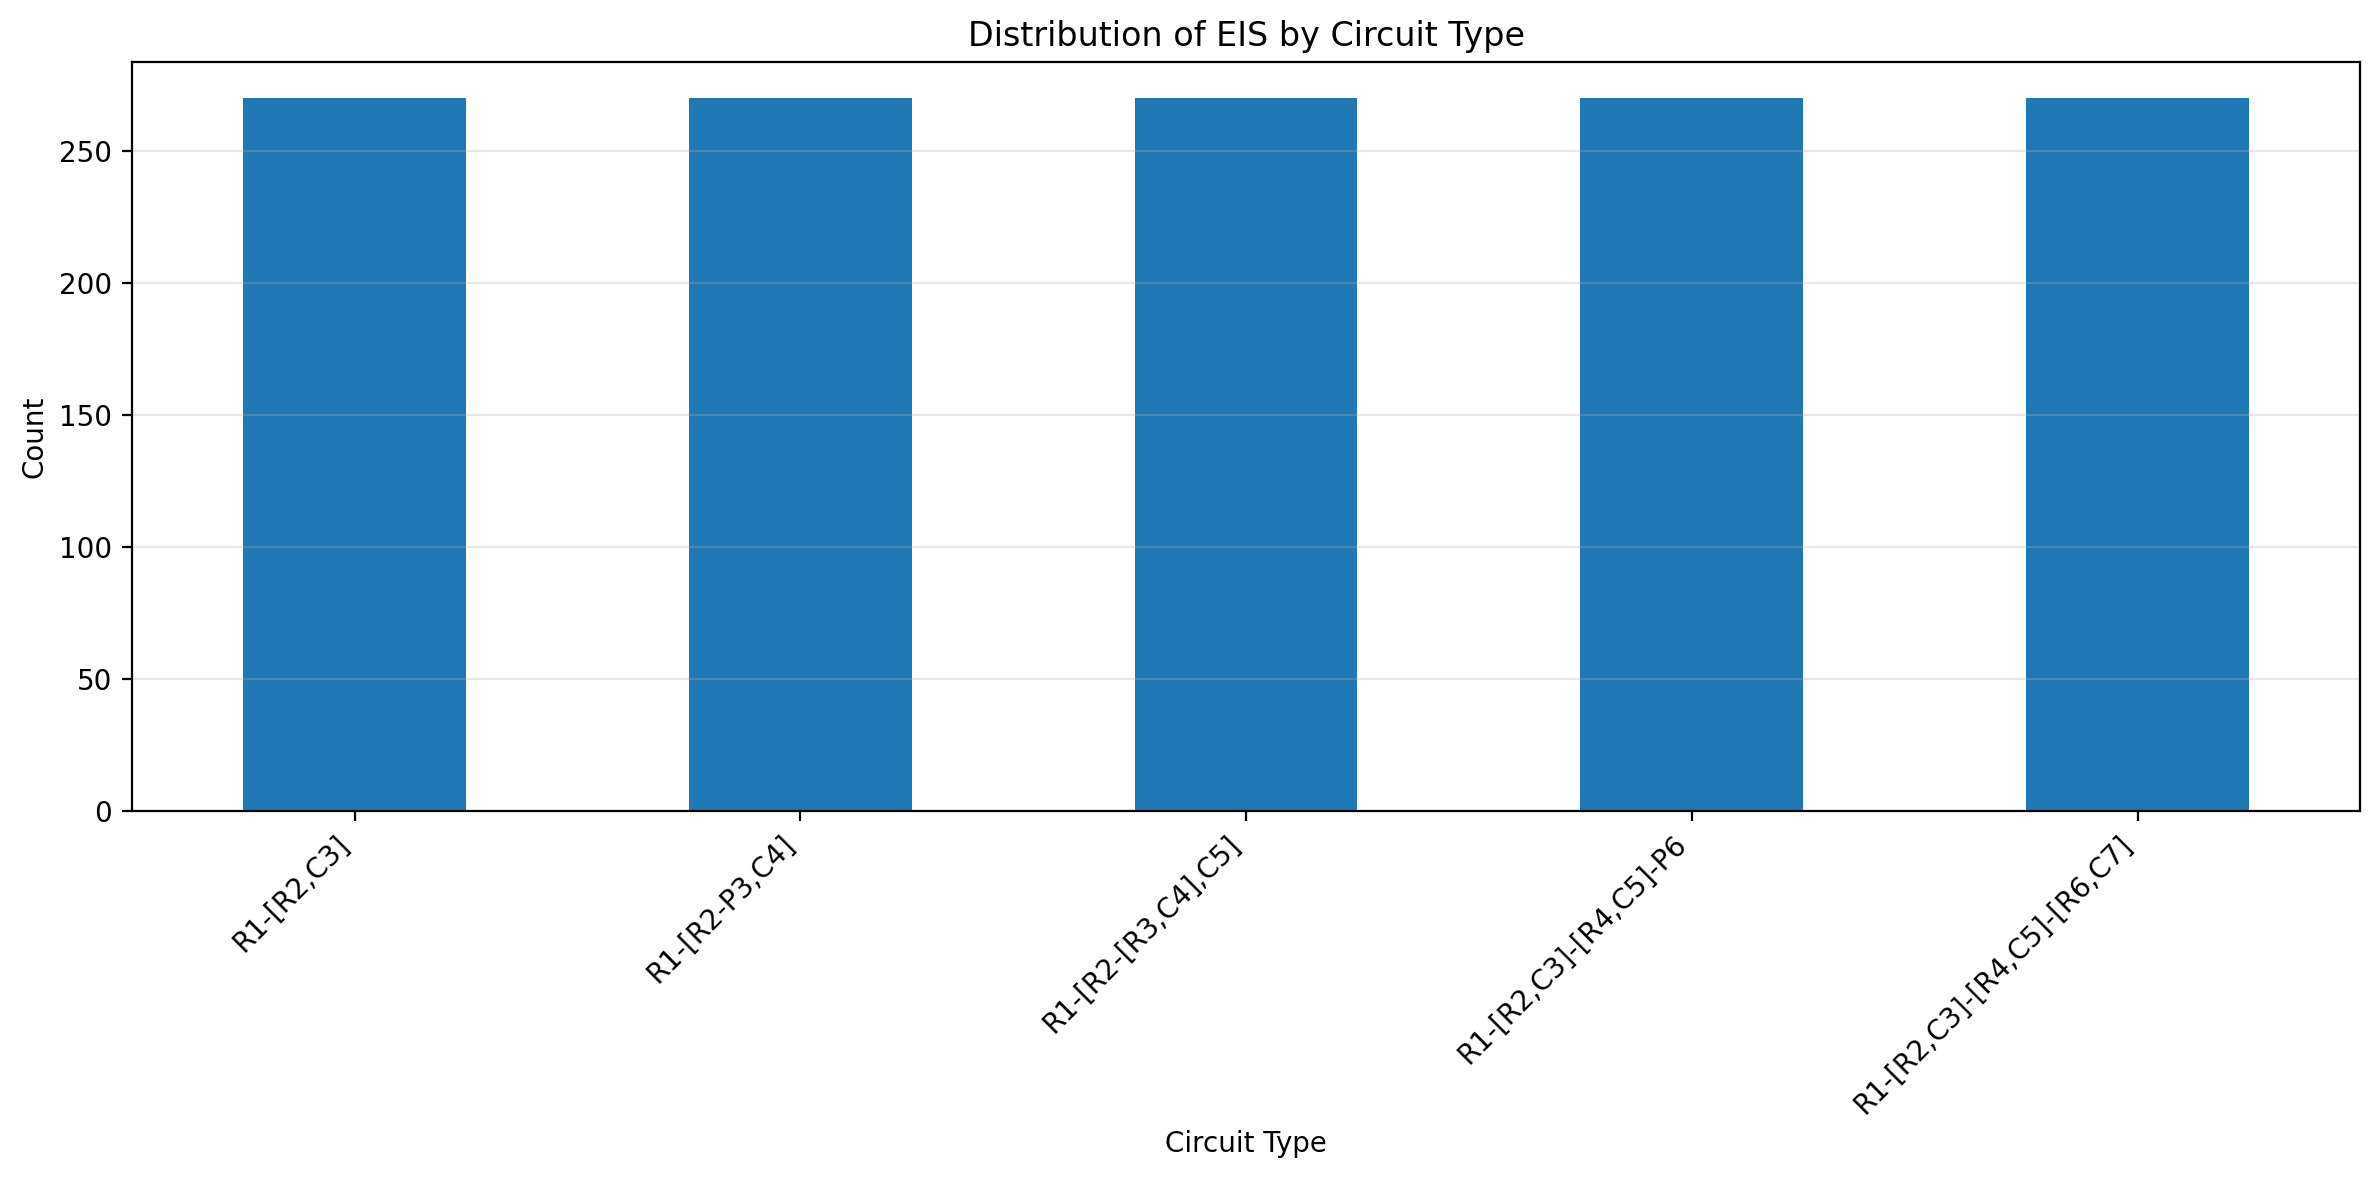

In [10]:
# If evaluation mode, check circuit distribution
if 'true_circuit' in dataset.columns:
    circuit_counts = dataset['true_circuit'].value_counts()
    print("Circuit Distribution:")
    print(circuit_counts)
    print(f"\nTotal unique circuits: {len(circuit_counts)}")
    
    # Plot distribution
    plt.figure(figsize=(12, 6))
    circuit_counts.plot(kind='bar')
    plt.xlabel('Circuit Type')
    plt.ylabel('Count')
    plt.title('Distribution of EIS by Circuit Type')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

---
## Ready for Training!

Your data is now prepared and ready to use with the RL agent. Key points:

✓ Dataset loaded with all required columns  
✓ EIS measurements normalized and flattened  
✓ Thresholds calculated for fitness evaluation  
✓ Ground truth circuits available (if evaluation mode)  

### Next Steps:
1. Move to **02_training_walkthrough.ipynb** to train the agent
2. Or save this dataset and use it in main.py/main_factory.py

### Tips:
- Save processed data as pickle for fast loading
- Check that all EIS have same number of frequency points
- Ensure reasonable threshold distributions
- Verify circuit labels if using evaluation mode